# Automated equity research pipeline

This notebook walks through a complete research workflow for a single stock:

1. **Load price history** — daily open, high, low, close, and volume.
2. **Compute technical indicators** — moving averages, RSI, MACD, and Bollinger Bands, implemented directly from formulas in Python.
3. **Fetch recent headlines** — public news items about the company.
4. **Generate a structured view** — a language model reads the technical snapshot plus headlines and returns BUY, HOLD, or SELL with rationale and risks.
5. **Evaluate honestly** — compare rule variants on held-out history, plot what happened after each signal type, and replay past dates without peeking at the future.

**Two decision layers work together:**

| Layer | What it does |
|-------|----------------|
| **Technical rule** | A deterministic momentum filter that maps indicators to BUY / HOLD / SELL. |
| **LLM analyst** | Synthesizes indicators and news into a readable research note. It is checked for valid output, not treated as proof of market-beating returns. |

**Configuration:** On your laptop, settings come from a `.env` file. In Google Colab, the same variable names are read from the Secrets panel. `src/config.py` picks the right source automatically.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# After you create the GitHub repo, put the HTTPS clone URL here.
REPO_URL = os.environ.get(
    "FINANCIAL_AI_REPO",
    "https://github.com/lavanblavan/Financial_AI.git",
)

def ensure_project() -> Path:
    if IN_COLAB:
        root = Path("/content/Financial_AI")
        if not (root / "src/config.py").exists():
            subprocess.run(["git", "clone", REPO_URL, str(root)], check=True)
        else:
            subprocess.run(["git", "-C", str(root), "pull", "--ff-only"], check=False)
        os.chdir(root)
    else:
        root = Path.cwd().resolve()
        if not (root / "src/config.py").exists():
            raise FileNotFoundError("Run this notebook from the repo root so src/ is visible.")

    req = root / "requirements.txt"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(req)], check=True)
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    return root

ROOT = ensure_project()
print("project root:", ROOT)
print("runtime:", "colab" if IN_COLAB else "local")

project root: /content/Financial_AI
runtime: colab


## Setup and configuration

The first code cell installs dependencies and locates the project folder. On Colab it clones the GitHub repository; locally it expects you to run the notebook from the repo root.

The next cell loads **settings**: ticker symbol (default AAPL), history length (default 2 years), and whether an LLM API key is available. If the key is missing, the pipeline still runs but falls back to the technical rule instead of calling the language model.

In [2]:
from src.config import describe_env, load_settings, missing_key_help

settings = load_settings()
print(describe_env(settings))
if not settings.llm_ready:
    print(missing_key_help(settings))

{'runtime': 'colab', 'secret_source': 'colab-secrets', 'ticker': 'AAPL', 'lookback': '2y', 'llm_provider': 'groq', 'llm_key_present': 'yes', 'groq_key_shape': 'gsk_*', 'groq_secret_status': 'present'}


In [3]:
from src.data import fetch_prices

prices = fetch_prices(settings.ticker, period=settings.lookback)
prices.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2026-09-04,328.309998,328.929993,317.859985,319.970001,39606900
2026-09-08,317.100006,320.700012,314.899994,316.220001,35477100
2026-09-09,315.489990,319.149994,309.899994,315.339996,65640000
2026-09-10,316.670013,326.739990,316.510010,326.570007,69925100
2026-09-11,327.630005,336.220001,326.299988,333.200989,31635027


## Price data

We download daily OHLCV bars for the chosen ticker. The table below shows the most recent rows: **Close** is the price we use for indicators; **Volume** tells us how actively the stock traded.

Data is cached under `data/` so repeat runs do not hammer the download API.

In [4]:
from src.indicators import add_indicators, latest_snapshot

df = add_indicators(prices)
snapshot = latest_snapshot(df)
display(df[["Close", "sma_50", "sma_200", "rsi_14", "macd", "macd_hist"]].tail())
snapshot

,Close,sma_50,sma_200,rsi_14,macd,macd_hist
Date,,,,,,
2026-09-04,319.970001,314.987768,283.439025,53.953206,2.641747,1.549596
2026-09-08,316.220001,315.641459,283.686555,50.256878,2.247662,0.924409
2026-09-09,315.339996,316.318314,283.924100,49.401551,1.843091,0.415871
2026-09-10,326.570007,317.067501,284.229314,58.992827,2.400958,0.778990
2026-09-11,333.200989,317.848994,284.541554,63.404009,3.339638,1.374137


{'date': '2026-09-11',
 'close': 333.20098876953125,
 'sma_50': 317.848994140625,
 'sma_200': 284.54155418396,
 'sma_cross': 'bullish',
 'sma_cross_flipped': False,
 'rsi_14': 63.40400866153907,
 'macd': 3.339638398625482,
 'macd_signal': 1.9655018849843766,
 'macd_hist': 1.3741365136411052,
 'bb_upper': 331.71989080185546,
 'bb_mid': 316.6725479125977,
 'bb_lower': 301.6252050233399,
 'bb_position': 'near_upper',
 'momentum_bias': 'bullish',
 'rule_variant': 'score'}

## Technical indicators

From the close price series we compute:

| Indicator | What it measures |
|-----------|------------------|
| **SMA 50 / SMA 200** | Average price over 50 and 200 sessions. When the shorter average is above the longer, the trend is usually considered bullish. |
| **RSI 14** | Momentum on a 0–100 scale. Above ~70 often means stretched/overbought; below ~30 often means oversold. |
| **MACD** | Difference between fast and slow trend lines, plus a signal line and histogram. Positive histogram → upward momentum. |
| **Bollinger Bands** | A moving average with upper/lower bands based on recent volatility. Price near the upper band → relatively high vs recent range. |

The **snapshot** dict is the last row summarised for the analyst: today's values and labels like `momentum_bias` (bullish / bearish / mixed), which the rule engine turns into BUY / HOLD / SELL.

## Technical charts

The charts below visualise roughly the **last year** of data. Read them top to bottom:

### Panel 1 — Price vs moving averages
- **Close** (price) compared with **SMA 50** and **SMA 200**.
- When the blue short line is **above** the orange long line, the stock is in an uptrend by this definition.
- Crossovers mark trend changes, but they lag price because averages smooth past data.

### Panel 2 — Bollinger Bands
- **Close** against upper, middle, and lower bands.
- Bands widen when volatility rises and narrow in quiet periods.
- Price hugging the **upper** band → strong recent move up; hugging the **lower** band → weak recent move.

### Panel 3 — RSI (14)
- Horizontal dashed lines at **30** and **70** mark common oversold / overbought zones.
- RSI in the **40–60** range usually means neutral momentum.
- RSI alone does not predict direction; it describes how stretched recent gains/losses are.

### Panel 4 — MACD
- **Lines** = MACD and its signal line; **bars** = histogram (MACD minus signal).
- Bars **above zero** → bullish momentum; **below zero** → bearish.
- Bars growing taller → momentum **accelerating**; shrinking → momentum **fading**.

### Interactive Plotly chart
The final figure lets you **zoom, pan, and hover** for exact dates and values. Use it when you need to inspect a specific week rather than the full-year summary.

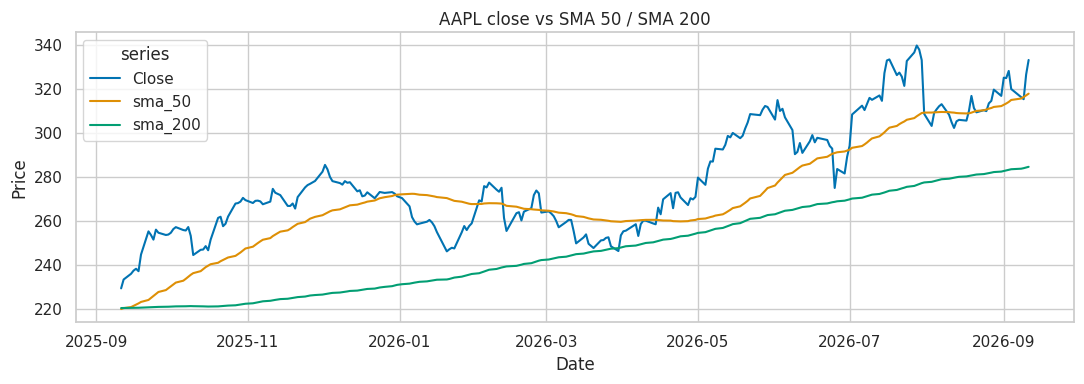

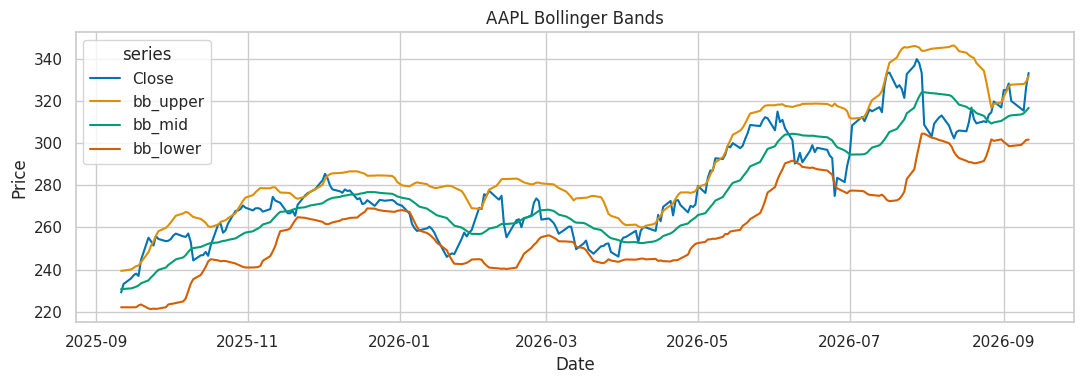

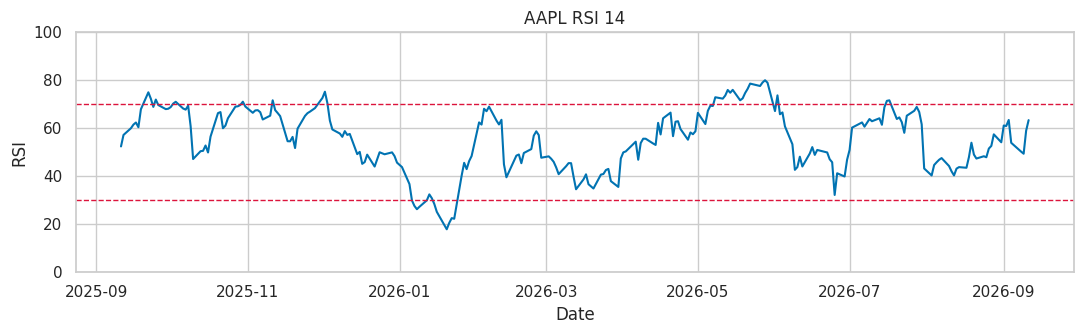

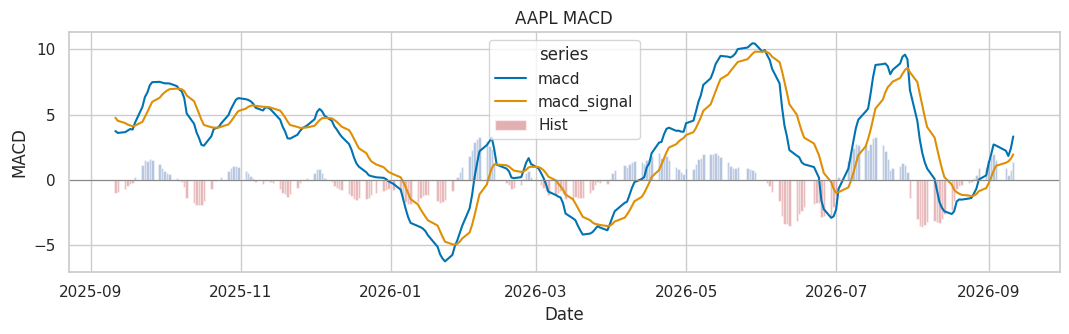

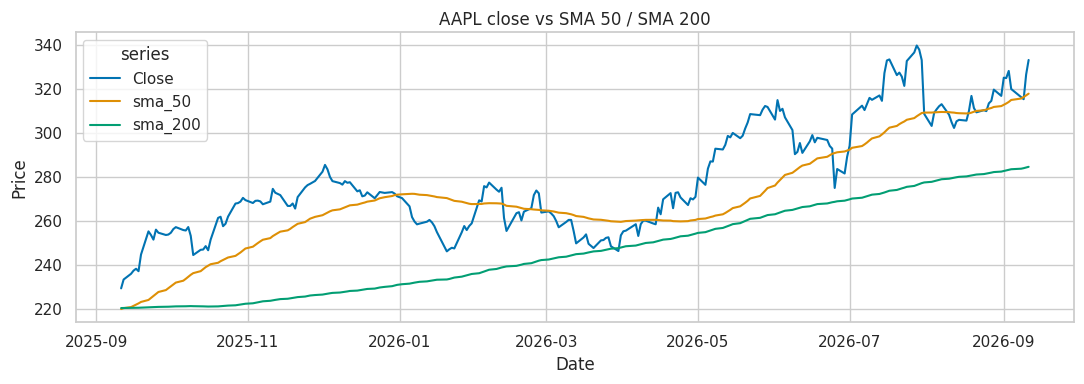

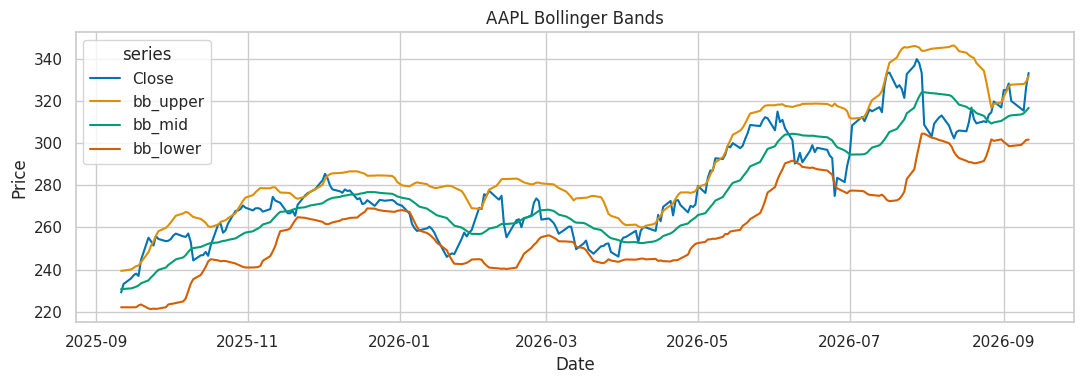

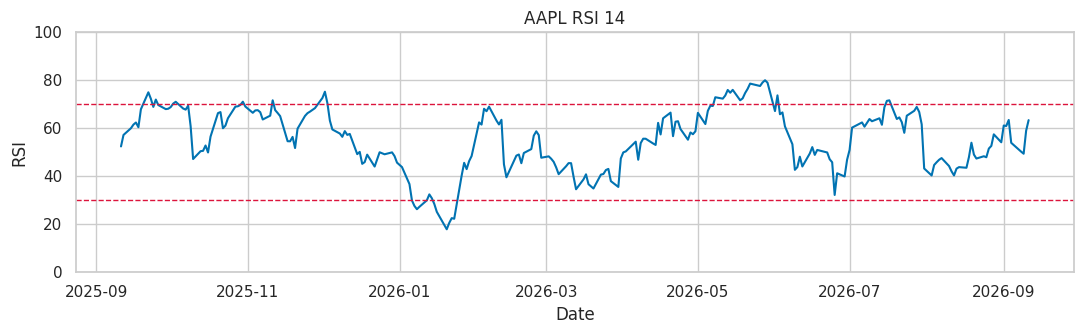

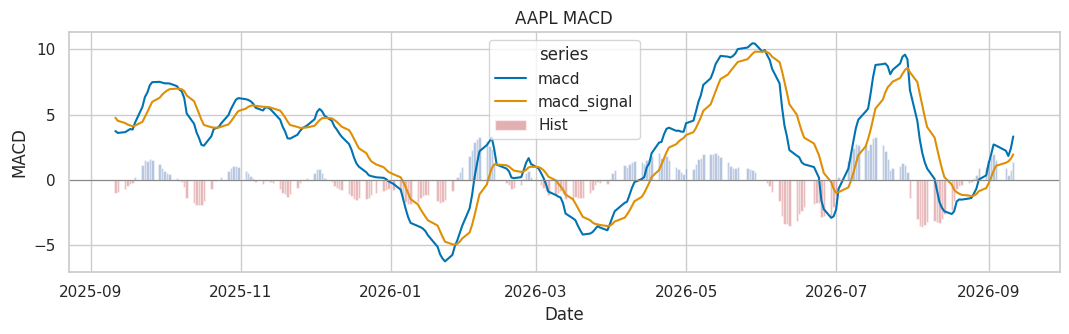

In [5]:
from src.plots import plot_all_seaborn, plot_interactive

for fig in plot_all_seaborn(df, ticker=settings.ticker):
    display(fig)

In [6]:
interactive = plot_interactive(df, ticker=settings.ticker)
interactive.show()

## News headlines

Recent public headlines about the ticker are collected from free sources (Yahoo Finance RSS and Google News). Each item has a **title**, **publisher**, and **date**.

**What this is for:** The LLM analyst uses headlines as context — for example, earnings news, product launches, or legal issues — alongside the technical snapshot. Headline coverage can be sparse or noisy; when news is thin, the model is instructed to prefer HOLD.

In [7]:
from src.news import fetch_news

headlines = fetch_news(settings.ticker, min_items=10)
print(f"{len(headlines)} headlines")
headlines

10 headlines


[{'title': "What a Republican 'wipeout' in the midterm elections means for investors",
  'publisher': 'Yahoo Finance Video',
  'date': '2026-09-11T12:00',
  'source': 'yfinance'},
 {'title': "Why hardware will attract buyers to Apple's new lineup over AI features",
  'publisher': 'Yahoo Finance Video',
  'date': '2026-09-10T19:29',
  'source': 'yfinance'},
 {'title': 'Apple Stock Has Returned Nearly 1,200% in 10 Years. How High Can AAPL Go From Here?',
  'publisher': '24/7 Wall St.',
  'date': '2026-09-11T17:30',
  'source': 'yfinance'},
 {'title': '‘Apple and Microsoft Look Like Value Stocks’: Morningstar on SanDisk’s 2,107% Year',
  'publisher': '24/7 Wall St.',
  'date': '2026-09-11T17:17',
  'source': 'yfinance'},
 {'title': 'Apple’s $164 Billion Rally Hinges on iPhone Duo Adoption Among 6 Million Premium Buyers',
  'publisher': '24/7 Wall St.',
  'date': '2026-09-11T17:15',
  'source': 'yfinance'},
 {'title': 'Stock Market Today: Dow Rallies On Surprise Inflation Data; Analog Devi

## LLM analyst signal

The language model receives:

- The **technical snapshot** (indicator values and labels)
- The **rule baseline** (`RULE_SIGNAL` from the deterministic filter)
- Up to ~10 **headlines**

It must return JSON only:

```json
{
  "signal": "BUY | HOLD | SELL",
  "confidence": 0.0 to 1.0,
  "rationale": "...",
  "bull_case": "...",
  "bear_case": "...",
  "risks": ["...", "..."]
}
```

**What to look for in the output:**
- Valid signal and confidence range
- Rationale that **combines** technicals and news, not a bullet list of indicators
- Explicit risks and both bull/bear cases
- HOLD when technicals and headlines conflict

If no API key is configured, you will see a HOLD placeholder and the technical rule is used instead.

In [8]:
from src.signal import GroqAPIError, LLMNotConfiguredError, build_signal

try:
    result = build_signal(snapshot, headlines, settings, settings.ticker)
except (LLMNotConfiguredError, GroqAPIError) as exc:
    result = {
        "signal": "HOLD",
        "confidence": 0.0,
        "horizon": "n/a",
        "rationale": str(exc),
        "bull_case": "",
        "bear_case": "",
        "risks": ["LLM key not configured"],
    }
result

{'signal': 'BUY',
 'confidence': 0.8,
 'horizon': '1-4 weeks',
 'rationale': 'Apple’s price sits above both the 50‑ and 200‑day moving averages with a bullish cross, and the MACD line and histogram are positive, confirming upward momentum. The RSI of 63.4 is in the neutral‑to‑bullish range, not yet overbought, while the price is only near the upper Bollinger band, suggesting room for a short‑term rally. Headlines emphasize strong hardware demand, the iPhone Duo launch, and a 1,200% decade‑long rally, all reinforcing bullish sentiment. Combined, these signals point to a moderate‑to‑strong conviction for a short‑term upside.',
 'bull_case': 'Apple’s recent hardware push, especially the iPhone Duo, is driving premium sales and boosting revenue. The company’s strong cash position and continued investment in R&D position it well for future product cycles, while the market’s positive sentiment and recent rally suggest further upside potential.',
 'bear_case': 'The stock’s proximity to the up

## One-page research brief

The brief is a self-contained HTML page saved under `outputs/`. It includes:

- The same charts shown above
- The indicator snapshot and headline list
- The LLM signal, confidence, rationale, bull/bear cases, and risks

**Purpose:** A human-readable summary you can open in a browser and share. It is **research output**, not personalised investment advice.

wrote /content/Financial_AI/outputs/AAPL_brief.html



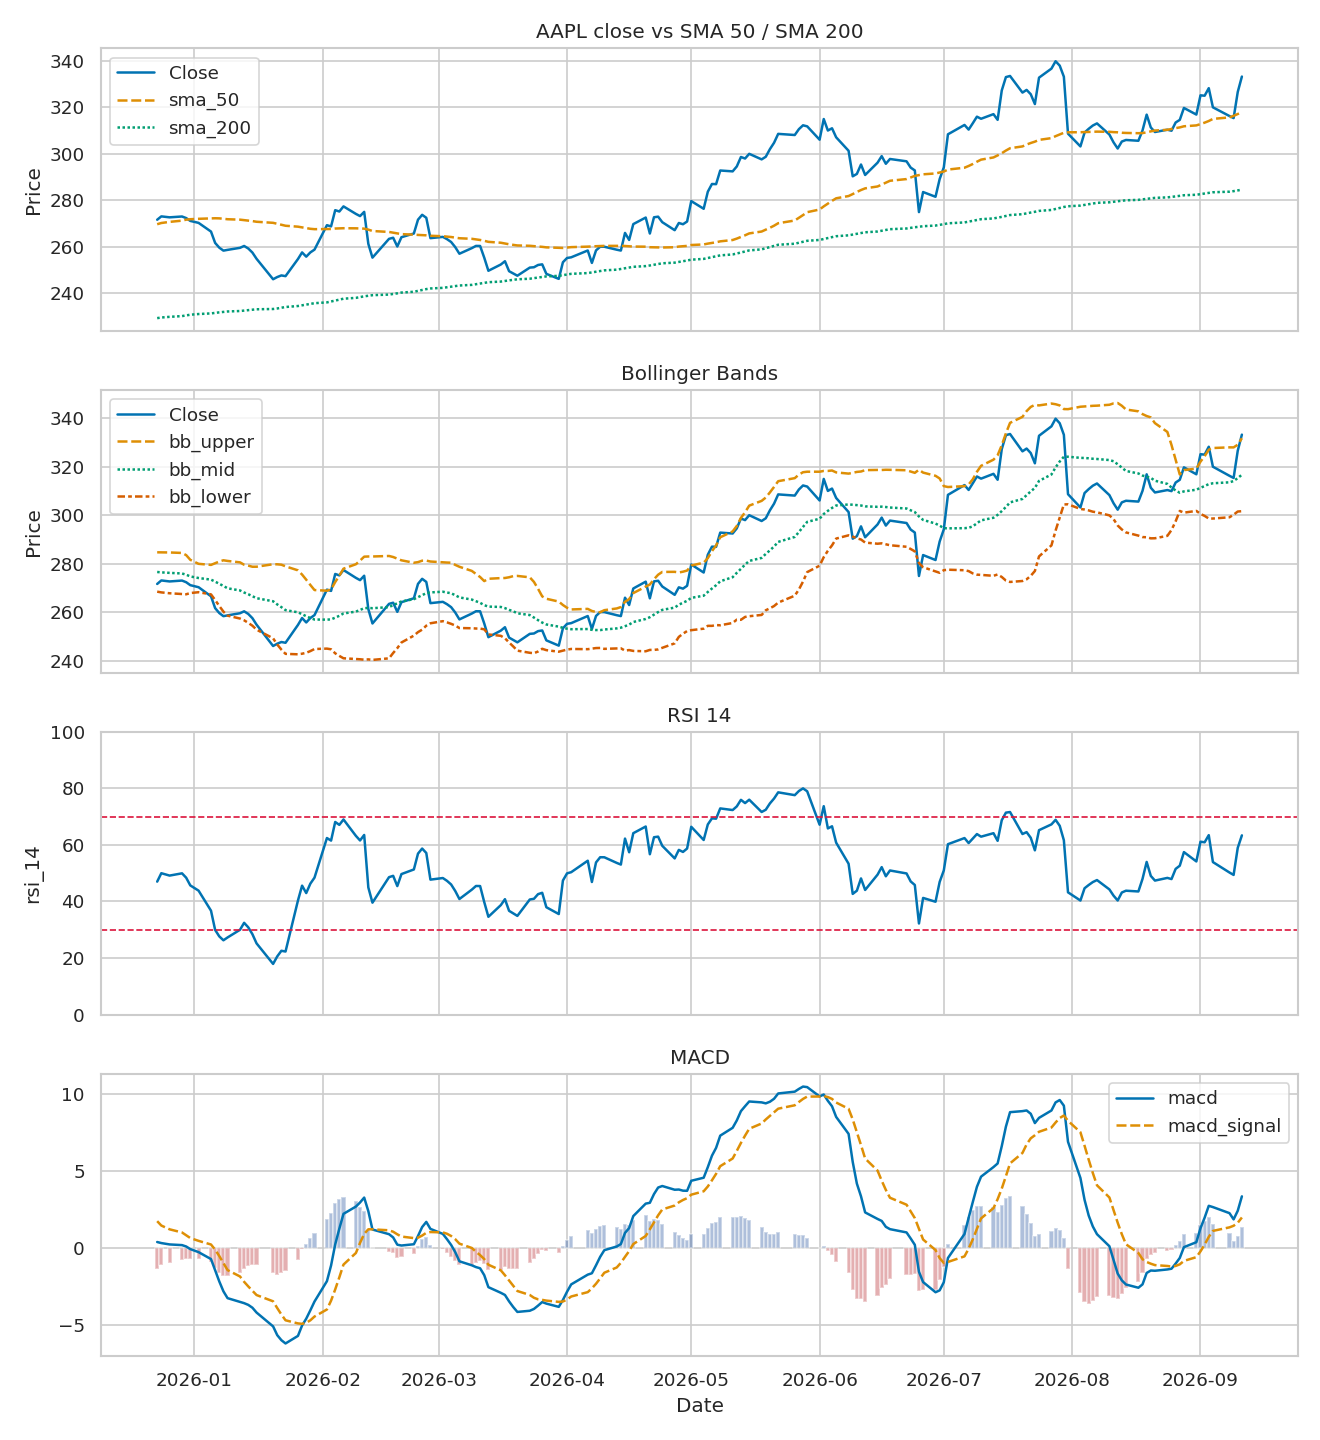

In [9]:
from IPython.display import HTML, display
from src.report import render_brief

brief_path = render_brief(settings.ticker, df, snapshot, headlines, result)
print("wrote", brief_path)
display(HTML(brief_path.read_text(encoding="utf-8")))

## How we evaluate the pipeline

Evaluation is split into separate questions. **Do not mix them** — a valid JSON note is not the same thing as a profitable trading rule.

### 1. Rule selection (holdout comparison)

Three momentum rules are compared on the **last 126 trading sessions only** — data the selection process never trained on:

| Variant | Idea |
|---------|------|
| **baseline** | Strict filter: uptrend + positive MACD + RSI in 45–70 |
| **acceleration** | Same, but MACD histogram must be **rising** and RSI in 50–65 |
| **score** | Score 5 conditions; BUY if ≥4 agree, SELL if bearish score ≥4 |

**Winner criteria:** Best **BUY minus SELL** average 10-day forward return, but only when both sides have at least 5 signals. Otherwise rank by holdout Sharpe. Details: `docs/RULE_SELECTION.md`.

The winning rule becomes the default technical baseline (`DEFAULT_RULE_VARIANT` in config).

### 2. Walk-forward tables

For each signal type (BUY / HOLD / SELL) we ask: *If the rule said this at the close, what was the average return over the next 10 sessions?*

| Column | Meaning |
|--------|---------|
| **n** | How many days that signal fired — small n → unstable averages |
| **mean_fwd_return** | Average next-10-day return after that signal |
| **hit_rate** | For BUY: % of times price went up; for SELL: % of times price went down |

We show **in-sample** (earlier history) and **holdout** (last ~6 months) separately so you can see whether patterns persist on unseen data.

### 3. Strategy stats

Simulates following the rule each day: **long** on BUY, **flat** on HOLD, **short** on SELL, compared with **buy-and-hold**. Reports total return, Sharpe ratio, and excess return. A rule can separate BUY from SELL and still lose to buy-and-hold — we report both.

### 4. Live LLM checks

Checks the **current** model JSON: valid signal, confidence in [0, 1], non-empty rationale, listed risks, no obvious contradiction (e.g. bearish trend + overbought RSI labelled BUY). This measures **output quality**, not whether the LLM beats the market.

The next section replays **past dates** with point-in-time news to score the LLM + rule together.

In [10]:
from src.config import DEFAULT_RULE_VARIANT
from src.evaluate import (
    add_forward_returns,
    compare_rule_variants,
    evaluate_llm_output,
    holdout_split,
    strategy_equity,
    strategy_stats,
    walk_forward_table,
)

rule_comparison, selected_rule, rule_rationale = compare_rule_variants(df, holdout_bars=126, horizon=10)
print("Rule variant holdout comparison")
display(rule_comparison)
print(f"Selected rule for pipeline: {selected_rule} (config default: {DEFAULT_RULE_VARIANT})")
print("Why:", rule_rationale)

scored = add_forward_returns(df)
in_sample, holdout = holdout_split(scored, holdout_bars=126)

print("In-sample (earlier history)")
display(walk_forward_table(in_sample, horizon=10))
print("Holdout (last ~6 months) — selected rule")
display(walk_forward_table(holdout, horizon=10))

equity = strategy_equity(holdout)
stats = strategy_stats(equity)
print(stats)

llm_eval = evaluate_llm_output(snapshot, result)
print("Live LLM checks:", llm_eval)

Rule variant holdout comparison


,variant,description,buy_n,sell_n,buy_mean_fwd,sell_mean_fwd,buy_sell_spread,buy_hit_rate,sell_hit_rate,strategy_sharpe,excess_return,strategy_total_return
0,baseline,Strict AND filter (SMA + MACD>0 + RSI 45-70),48,0,0.029635,NaN,0.029635,0.791667,NaN,2.608437,-0.043309,0.291232
1,acceleration,Trend + rising MACD histogram + RSI 50-65,15,0,0.046559,NaN,0.046559,1.000000,NaN,1.338391,-0.279389,0.055153
2,score,"Confluence score >=4/5 (SMA, MACD, MACD rising...",52,14,0.028673,0.008061,0.020612,0.788462,0.285714,0.663197,-0.274172,0.060369


Selected rule for pipeline: score (config default: score)
Why: {'selected_variant': 'score', 'description': 'Confluence score >=4/5 (SMA, MACD, MACD rising, RSI, vs BB mid)', 'buy_sell_spread': np.float64(0.020611900359029524), 'strategy_sharpe': 0.6631971746465019, 'excess_return': -0.2741724837637505, 'buy_n': 52, 'sell_n': 14, 'used_buy_sell_spread': True, 'min_directional': 5, 'ranking': [{'variant': 'score', 'buy_sell_spread': 0.020611900359029524, 'strategy_sharpe': 0.6631971746465019, 'excess_return': -0.2741724837637505}, {'variant': 'baseline', 'buy_sell_spread': 0.02963507424150856, 'strategy_sharpe': 2.60843674163217, 'excess_return': -0.04330945530511654}, {'variant': 'acceleration', 'buy_sell_spread': 0.04655869919696398, 'strategy_sharpe': 1.3383914974443238, 'excess_return': -0.27938904351477944}]}
In-sample (earlier history)


,signal,n,mean_fwd_return,hit_rate
0,BUY,41,-0.002065,0.463415
1,HOLD,112,0.011968,NaN
2,SELL,24,0.031703,0.541667


Holdout (last ~6 months) — selected rule


,signal,n,mean_fwd_return,hit_rate
0,BUY,52,0.028673,0.788462
1,HOLD,50,0.021803,NaN
2,SELL,14,0.008061,0.285714


{'strategy_total_return': 0.0603693732345969, 'buy_hold_total_return': 0.3345418569983474, 'strategy_sharpe': 0.6631971746465019, 'buy_hold_sharpe': 2.2300949431771913, 'excess_return': -0.2741724837637505}
Live LLM checks: {'schema_ok': True, 'signal': 'BUY', 'rule_signal': 'BUY', 'agrees_with_rule': True, 'overbought_buy_conflict': False, 'has_rationale': True, 'n_risks': 3}


## Reading the evaluation charts

### Bar chart — mean forward return by signal

Each bar is the **average 10-day return** after the rule said BUY, HOLD, or SELL on holdout data.

- Bar **above zero** → that signal tended to precede positive returns on average.
- Bar **below zero** → negative average follow-through.
- **HOLD** near zero is normal — it means "no strong view," not a failed prediction.

Compare BUY vs SELL height: a useful rule usually shows **BUY bar higher than SELL bar**, even if both are modest.

### Line chart — equity curve

Two cumulative return lines on the holdout window:

| Line | Meaning |
|------|---------|
| **strategy** | P&L from following the rule (long / flat / short) day by day |
| **buy_hold** | P&L from buying once and doing nothing |

If **strategy** runs below **buy_hold**, the rule underperformed simply owning the stock in that period — report that honestly. Outperformance is not guaranteed; the chart shows what actually happened.

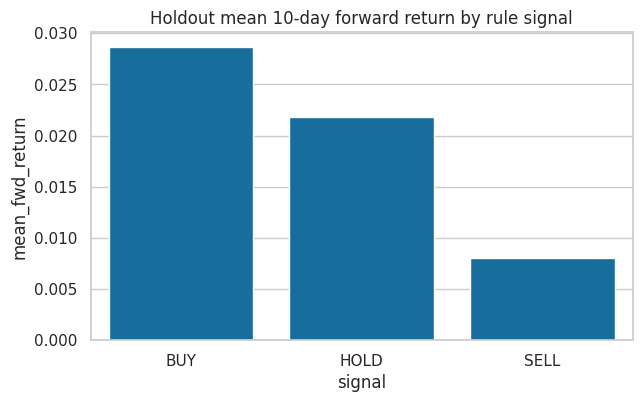

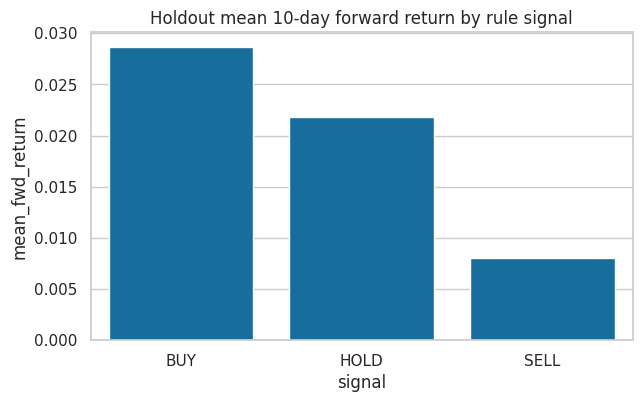

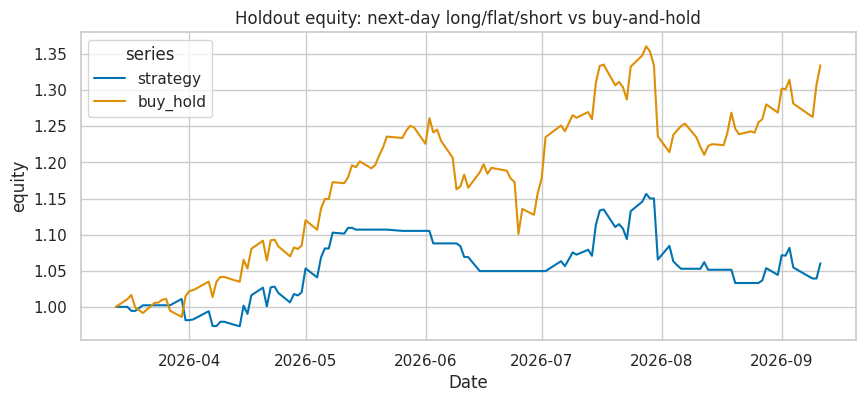

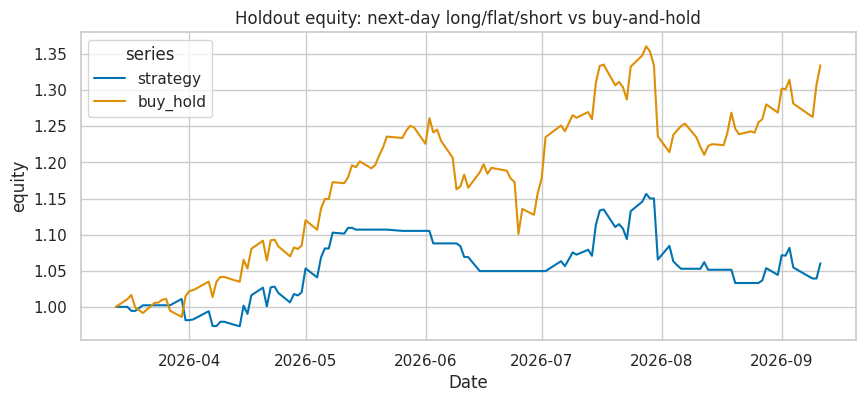

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

table = walk_forward_table(holdout, horizon=10)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=table, x="signal", y="mean_fwd_return", ax=ax)
ax.axhline(0, color="#888", linewidth=0.8)
ax.set_title("Holdout mean 10-day forward return by rule signal")
ax.set_ylabel("Mean forward return")
display(fig)
plt.close(fig)

eq_plot = equity[["strategy", "buy_hold"]].rename_axis("Date")
eq_long = eq_plot.reset_index().melt(id_vars="Date", var_name="series", value_name="equity")
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=eq_long, x="Date", y="equity", hue="series", ax=ax)
ax.set_title("Holdout equity: rule strategy vs buy-and-hold")
ax.set_ylabel("Cumulative return (1 = starting value)")
display(fig)
plt.close(fig)

## Historical replay — May 2026

This section answers: *"If we had run the pipeline on past dates, using only information available then, would the calls have been right?"*

### Protocol (no look-ahead)

For each decision date in May 2026:

1. **Prices** — indicators computed using data **up to that day's close only**.
2. **News** — headlines from GDELT with a seen-date in the **prior 14 days** (public dated archive).
3. **Decision** — LLM signal (or technical rule fallback if the API is unavailable).
4. **Reality check** — compare to the actual close **10 trading sessions later**.

### How to read the replay table

| Column | Meaning |
|--------|---------|
| **date** | Decision day |
| **signal** | What the pipeline recommended (BUY / HOLD / SELL) |
| **rule_signal** | What the deterministic rule alone would have said |
| **n_headlines** | How many news items were available — low counts mean thin context |
| **fwd_return** | Actual % change over the next 10 sessions |
| **actual_move** | UP or DOWN based on that return |
| **match** | Yes if BUY→UP or SELL→DOWN; HOLD is not scored as right/wrong |

### Summary metrics

- **Directional accuracy** — % correct among **BUY and SELL only** (HOLD is excluded because it is not a directional bet).
- **Mean return after BUY / SELL** — average realised return following each signal type.

### What to expect

- Accuracy with only a handful of BUY/SELL rows is **not statistically robust** — treat percentages as descriptive.
- Many HOLDs mean the system is conservative, not broken.
- GDELT is a free public index, not a full professional newswire — headline gaps are normal.
- This is a **research diagnostic**, not proof the system will make money in the future.

In [12]:
from IPython.display import HTML, display
from src.replay import render_replay_report, replay_history, replay_summary

# step=21 ≈ one decision per month. use_llm=True uses Groq; set False to score the rule only.
replay = replay_history(
    prices,
    settings.ticker,
    settings=settings,
    start="2026-05-01",
    end="2026-05-31",
    step=2,
    horizon=10,
    use_llm=True,
)
summary = replay_summary(replay)
display(replay[["date", "signal", "rule_signal", "n_headlines", "fwd_return", "actual_move", "match"]])
print(summary)

replay_path = render_replay_report(settings.ticker, replay, summary, horizon=10)
print("wrote", replay_path)
display(HTML(open(replay_path, encoding="utf-8").read()))

,date,signal,rule_signal,n_headlines,fwd_return,actual_move,match
0,2026-05-01,BUY,BUY,8,0.072702,UP,True
1,2026-05-05,BUY,BUY,8,0.053014,UP,True
2,2026-05-07,BUY,BUY,8,0.062034,UP,True
3,2026-05-11,HOLD,BUY,8,0.053471,UP,False
4,2026-05-13,BUY,BUY,8,0.045639,UP,True
5,2026-05-15,HOLD,HOLD,8,0.020251,UP,False
6,2026-05-19,HOLD,HOLD,8,0.037763,UP,False
7,2026-05-21,HOLD,HOLD,8,0.007705,UP,False
8,2026-05-26,HOLD,HOLD,8,-0.057665,DOWN,False
9,2026-05-28,HOLD,HOLD,8,-0.054014,DOWN,False


{'n_dates': 10, 'n_buy': 4, 'n_sell': 0, 'n_hold': 6, 'n_directional': 4, 'directional_accuracy': 1.0, 'mean_return_after_buy': 0.05834688573632857, 'mean_return_after_sell': None, 'n_with_headlines': 10}
wrote /content/Financial_AI/outputs/AAPL_replay.html


Date,Close,Signal,Technical rule,Headlines,Next 10d,Realised,Correct direction,Lead headline
2026-05-01,279.64,BUY,BUY,8,7.27%,UP,Yes,"Ahead of Earnings, Is Apple Stock a Buy, a Sell, or Fairly Valued? - Morningstar"
2026-05-05,283.67,BUY,BUY,8,5.30%,UP,Yes,"Apple (AAPL) Stock Trades Up, Here Is Why - Yahoo Finance"
2026-05-07,286.93,BUY,BUY,8,6.20%,UP,Yes,"Apple (AAPL) Stock Trades Up, Here Is Why - Yahoo Finance"
2026-05-11,292.43,HOLD,BUY,8,5.35%,UP,No,"Apple (AAPL) Stock Trades Up, Here Is Why - Yahoo Finance"
2026-05-13,298.61,BUY,BUY,8,4.56%,UP,Yes,"Apple (AAPL) Stock Trades Up, Here Is Why - Yahoo Finance"
2026-05-15,299.97,HOLD,HOLD,8,2.03%,UP,No,"Apple (AAPL) Stock Trades Up, Here Is Why - Yahoo Finance"
2026-05-19,298.71,HOLD,HOLD,8,3.78%,UP,No,"Apple Stock Shares Rally 16% In A Month, Should You Buy The Stock? - Trefis"
2026-05-21,304.73,HOLD,HOLD,8,0.77%,UP,No,"Apple Stock Shares Rally 16% In A Month, Should You Buy The Stock? - Trefis"
2026-05-26,308.06,HOLD,HOLD,8,-5.77%,DOWN,No,"Apple Stock Shares Rally 16% In A Month, Should You Buy The Stock? - Trefis"
2026-05-28,312.24,HOLD,HOLD,8,-5.40%,DOWN,No,"Apple Stock Shares Rally 16% In A Month, Should You Buy The Stock? - Trefis"
